### 텍스트 전처리
- 지저분한 텍스트를 정규표현식으로 정리
- 데이터를 정제해서 전후로 비교
- 뉴스 격식체, 실제 리뷰(구어체) 어떻게 다른지 확인해보기
- 정제 과정을 -> 함수로 만들어서 계속 재사용

- 뉴스원본.csv -> 네이버 뉴스 1000건(경제, IT, 과학 등)
- 제주관광공사 비짓제주 리뷰 5917건(공공데이터포털) -> encoding이 cp949

- 지저분한 데이터 : 
    1. 공백 너무 많음
    2. 특수문자가 많다
    3. 언론사 이름, 링크, 이메일 -> 이런 것들은 사실상 내용 자체에는 중요하지 않은 요소

- 리뷰데이터의 경우
    1. 감탄사
    2. 붙여쓰기
    3. 오타
    4. 이모지(이모티콘)
    5. 반복 문자 -> ㅋㅋㅋ, ㅎㅎㅎ 등

### 1. 뉴스 데이터
- 정제 시작

In [76]:
import pandas as pd

df = pd.read_csv("../data/11-1_뉴스원본.csv")
df.head(3)

,제목,본문,카테고리,요약,출처URL
0,현대백화점그룹 더현대 광주 추진,서울 연합뉴스 현대백화점그룹이 광주광역시에 서울 여의도 더현대 서울 과 같은 문화복...,경제,"6 6일 현대백화점그룹이 광주시에 문화복합몰을 만든다고 6일 밝혔으며, 광주시는 서...",https://n.news.naver.com/mnews/article/001/001...
1,이스타항공 이상직 회사와 무관…오해 살 언동 말아야,전주 뉴시스 김얼 기자 이스타항공 자금 배임·횡령으로 전주교도소에 수감됐었던 이상직...,경제,이이스항공은 자금 배임·횡령으로 전주교도소에 수감됐었던 이상직 전 의원이 출소한 것...,https://n.news.naver.com/mnews/article/003/001...
2,농협은행 농협금융 출범 10주년 기념주화 NFT 이벤트,NH농협은행은 올해 농협금융 출범 10주년을 맞아 이달 29일까지 ‘10주년 기념주...,경제,NH농협은행은 올해 농협금융 출범 10주년을 맞아 이달 29일까지 소셜미디어 인스타...,https://n.news.naver.com/mnews/article/366/000...


In [77]:
df[['제목', '본문']].head(3)

,제목,본문
0,현대백화점그룹 더현대 광주 추진,서울 연합뉴스 현대백화점그룹이 광주광역시에 서울 여의도 더현대 서울 과 같은 문화복...
1,이스타항공 이상직 회사와 무관…오해 살 언동 말아야,전주 뉴시스 김얼 기자 이스타항공 자금 배임·횡령으로 전주교도소에 수감됐었던 이상직...
2,농협은행 농협금융 출범 10주년 기념주화 NFT 이벤트,NH농협은행은 올해 농협금융 출범 10주년을 맞아 이달 29일까지 ‘10주년 기념주...


### 2. 정규 표현식이란?
- "~ 이런 문자를 찾아라"를 적는 규칙
- 숫자로 시작하는 단어나, http로 시작하는 링크와 같은 패턴을 기호로 적는 방법
- re.sub(찾을 규칙, 바꿀 것, 텍스트) -> 원하는 부분을 찾아서 바꿔줌
- \s : 공백이 아닌 글자
- [^...] : 이것들이 아닌 것

#### 경우 1
- URL을 지우고 싶다
- http로 시작해서 공백 전까지 이어지는 부분 지워보기

In [78]:
import re

sample = "행사 안내입니다. https://events.com/2026 참고하세요."

# 링크 제거해보자!

result = re.sub(r"http\S+", "", sample) # + 대신 *를 넣어도 같은 결과!
print(result)

행사 안내입니다.  참고하세요.


#### 경우 2
- 이메일을 지우고 싶을 때

In [79]:
sample = "문의는 jsw@news.com 으로 주세요"

result = re.sub(r"\S+@\S+", "", sample) # 공백이 아닌 글자들 + @ + 공백이 아닌 글자들 의미!

print(result)

문의는  으로 주세요


#### 경우 3
- 특수문자를 지우고 싶을 때

In [80]:
sample = "삼성전자 주가 20% 상승!! (역대 최고 상승)"

result = re.sub(r"[^가-힣a-zA-Z0-9\s]", " ", sample) # ^괄호 안에 적은 것을 제외한 문자만 남김 (예를 들어 뒤에 0-9 지우면 숫자도 사라짐)

print(result)

삼성전자 주가 20  상승    역대 최고 상승 


#### 경우 4
- 공백이 많은 경우 -> 특수문자 지우거나 하면 공백이 생기므로, 하나이상의 공백을 하나로 바꾸기

In [81]:
sample = "  삼성전자   주가 20  상승    역대 최고  상승 "

result = re.sub(r"\s+", " ", sample)    # 여기 s는 소문자 써야 함..!
print(result)

 삼성전자 주가 20 상승 역대 최고 상승 


In [82]:
# 번외 - 숫자 없애기
sample = "삼성전자 주가 20 상승 역대 최고 상승"
result = re.sub(r"[0-9]", "", sample)   # 아까완 달리 ^ 없으므로 숫자만 제거하는 코드 됨
print(result)

삼성전자 주가  상승 역대 최고 상승


### 3. 정규화
- 정제 -> 불필요한 것 지우는 거라면
- 정규화 -> 같은 의미인데 다르게 적힌 표기를 하나로 통일하는 것!
- 예)
    - Apple, apple -> 같은 단어
    - 대소문자 통일, 공백, 반복문자 정리 등
    - 유니코드 정규화

### 4. 경우들을 묶어서 한꺼번에 처리하는 함수 만들기
- 정제함수 만들기
    1. URL 제거하기
    2. 이메일 제거
    3. 특수문자 제거
    4. 공백처리

In [83]:
def clean_news_title(text):
      # 1. URL 제거
      text = re.sub(r"https?://\S+", " ", text)

      # 2. 이메일 제거
      text = re.sub(r"\S+@\S+", " ", text)

      # 3. 특수문자 제거
      # 한글, 영어, 숫자, 공백만 남깁니다.
      text = re.sub(r"[^가-힣a-zA-Z0-9\s]", " ", text)

      # 4. 여러 공백을 한 칸으로 바꾸고, 앞뒤 공백 제거
      text = re.sub(r"\s+", " ", text).strip()

      return text

In [84]:
df['본문'][3]

'img tag s 지난 30일 서울의 한 주유소. 〈사진 연합뉴스〉 img tag e 오늘 1일 부터 유류세율 인하 폭이 확대됩니다. 올해 3분기에는 생애최초 주택 구매 대출 규제도 완화됩니다. 기획재정부에 따르면 정부는 계속되는 고유가 상황에 따라 국민의 유류비 부담 완화를 위해 이날부터 유류세를 법정 최대한도인 37%로 인하합니다. img tag s 〈사진 기획재정부〉 img tag e 기존 30%에서 대통령령으로 가능한 최대폭까지 확대한 겁니다. 이에 따라 휘발유는 리터당 57원 경유는 38원 LPG는 12원 싸집니다. img tag s 〈사진 기획재정부〉 img tag e 또 오는 10월부터는 코로나19 피해로 대출상환에 어려움을 겪는 소상공인과 자영업자를 위한 채무조정 프로그램도 시행합니다. 최대 30조원 규모로 소상공인·자영업자 새출발기금 가칭 을 설립해 대출채권 매입 등의 방식으로 상환일정 조정과 채무감면을 지원할 계획입니다. img tag s 〈사진 기획재정부〉 img tag e 부동산 대출 규제도 완화합니다. 생애 최초 주택 구매자에 대해서는 LTV 상한을 주택 소재 지역이나 가격 소득과 상관없이 80%로 완화합니다. 올해 3분기 중에 시행할 계획입니다. 지금은 투기과열지구 경우 LTV가 60%까지 조정대상지역은 70%까지 적용되고 있습니다. 이외에 올해 하반기에 바뀌는 정책은 기획재정부 홈페이지와 지자체 공공기관 등에서 확인할 수 있습니다.'

In [85]:
result = clean_news_title(df['본문'][3])
print(result)

img tag s 지난 30일 서울의 한 주유소 사진 연합뉴스 img tag e 오늘 1일 부터 유류세율 인하 폭이 확대됩니다 올해 3분기에는 생애최초 주택 구매 대출 규제도 완화됩니다 기획재정부에 따르면 정부는 계속되는 고유가 상황에 따라 국민의 유류비 부담 완화를 위해 이날부터 유류세를 법정 최대한도인 37 로 인하합니다 img tag s 사진 기획재정부 img tag e 기존 30 에서 대통령령으로 가능한 최대폭까지 확대한 겁니다 이에 따라 휘발유는 리터당 57원 경유는 38원 LPG는 12원 싸집니다 img tag s 사진 기획재정부 img tag e 또 오는 10월부터는 코로나19 피해로 대출상환에 어려움을 겪는 소상공인과 자영업자를 위한 채무조정 프로그램도 시행합니다 최대 30조원 규모로 소상공인 자영업자 새출발기금 가칭 을 설립해 대출채권 매입 등의 방식으로 상환일정 조정과 채무감면을 지원할 계획입니다 img tag s 사진 기획재정부 img tag e 부동산 대출 규제도 완화합니다 생애 최초 주택 구매자에 대해서는 LTV 상한을 주택 소재 지역이나 가격 소득과 상관없이 80 로 완화합니다 올해 3분기 중에 시행할 계획입니다 지금은 투기과열지구 경우 LTV가 60 까지 조정대상지역은 70 까지 적용되고 있습니다 이외에 올해 하반기에 바뀌는 정책은 기획재정부 홈페이지와 지자체 공공기관 등에서 확인할 수 있습니다


In [86]:
df['정제본문'] = df['본문'].apply(clean_news_title)
df.head(3)

,제목,본문,카테고리,요약,출처URL,정제본문
0,현대백화점그룹 더현대 광주 추진,서울 연합뉴스 현대백화점그룹이 광주광역시에 서울 여의도 더현대 서울 과 같은 문화복...,경제,"6 6일 현대백화점그룹이 광주시에 문화복합몰을 만든다고 6일 밝혔으며, 광주시는 서...",https://n.news.naver.com/mnews/article/001/001...,서울 연합뉴스 현대백화점그룹이 광주광역시에 서울 여의도 더현대 서울 과 같은 문화복...
1,이스타항공 이상직 회사와 무관…오해 살 언동 말아야,전주 뉴시스 김얼 기자 이스타항공 자금 배임·횡령으로 전주교도소에 수감됐었던 이상직...,경제,이이스항공은 자금 배임·횡령으로 전주교도소에 수감됐었던 이상직 전 의원이 출소한 것...,https://n.news.naver.com/mnews/article/003/001...,전주 뉴시스 김얼 기자 이스타항공 자금 배임 횡령으로 전주교도소에 수감됐었던 이상직...
2,농협은행 농협금융 출범 10주년 기념주화 NFT 이벤트,NH농협은행은 올해 농협금융 출범 10주년을 맞아 이달 29일까지 ‘10주년 기념주...,경제,NH농협은행은 올해 농협금융 출범 10주년을 맞아 이달 29일까지 소셜미디어 인스타...,https://n.news.naver.com/mnews/article/366/000...,NH농협은행은 올해 농협금융 출범 10주년을 맞아 이달 29일까지 10주년 기념주화...


In [87]:
## 시각화 체크

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px  

plt.rcParams["font.family"] = "Malgun Gothic"   # 한글 깨짐 방지(윈도우 기본 폰트)
plt.rcParams["axes.unicode_minus"] = False

In [88]:
df['본문'].str.len()

0        62
1       941
2       426
3       714
4       920
       ... 
995    1187
996    1430
997    3574
998    1679
999    1492
Name: 본문, Length: 1000, dtype: int64

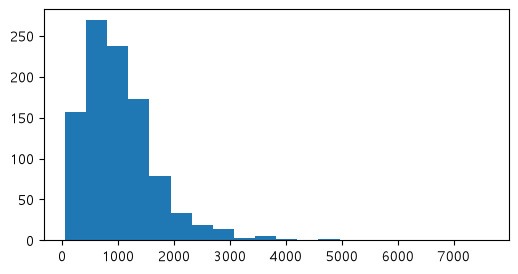

In [89]:
plt.figure(figsize=(6,3))
plt.hist(df['본문'].str.len(), bins=20, label="원본")
plt.show()

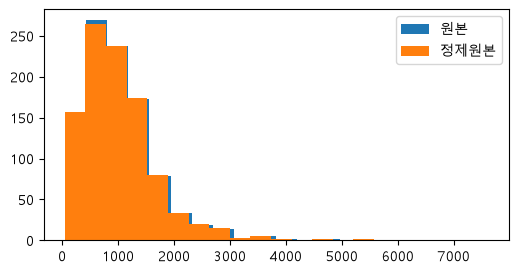

In [90]:
plt.figure(figsize=(6,3))
plt.hist(df['본문'].str.len(), bins=20, label="원본")
plt.hist(df['정제본문'].str.len(), bins=20, label="정제원본")
plt.legend()
plt.show()
# 차이 그렇게 크게 나진 않음

### 5. 실전 비짓제주 데이터 처리해보기
- 관광 리뷰 데이터

In [91]:
jeju = pd.read_csv("../data/11-1_visitjeju_reviews.csv", encoding="cp949")
jeju.head()

,리뷰내용,추천수
0,제주특별자치도 서귀포시 안덕면 병악로 166 에 위치한 카멜리아힐동백언덕.친구들과함...,159
1,"성이시돌목장에 가면 테쉬폰, 우유부단 뿐만 아니라 왕따나무도 이색볼거리로 손꼽히고 ...",132
2,메밀꽃 지평선과 하늘입니다,57
3,#제주소녀 #엄샤 #제주도민 #도민추천 #인생샷 #명소 #인생샷명소 #해바라기 #꽃밭,29
4,#제주소녀 #엄샤 #도민추천 #먹이주기체험 #양떼목장 #애월읍 #체험학습 #육아,29


In [92]:
jeju.sort_values("추천수", ascending=False).head()
# 원본 데이터 자체가 추천수 정렬돼 있었음 확인할 수 있다!

,리뷰내용,추천수
0,제주특별자치도 서귀포시 안덕면 병악로 166 에 위치한 카멜리아힐동백언덕.친구들과함...,159
1,"성이시돌목장에 가면 테쉬폰, 우유부단 뿐만 아니라 왕따나무도 이색볼거리로 손꼽히고 ...",132
2,메밀꽃 지평선과 하늘입니다,57
3,#제주소녀 #엄샤 #제주도민 #도민추천 #인생샷 #명소 #인생샷명소 #해바라기 #꽃밭,29
4,#제주소녀 #엄샤 #도민추천 #먹이주기체험 #양떼목장 #애월읍 #체험학습 #육아,29


In [93]:
jeju.isna().sum()

리뷰내용    489
추천수       0
dtype: int64

In [94]:
jeju_clean = jeju.dropna(subset="리뷰내용")

In [95]:
jeju_clean['정제리뷰'] = jeju_clean['리뷰내용'].apply(clean_news_title)
jeju_clean.head()

,리뷰내용,추천수,정제리뷰
0,제주특별자치도 서귀포시 안덕면 병악로 166 에 위치한 카멜리아힐동백언덕.친구들과함...,159,제주특별자치도 서귀포시 안덕면 병악로 166 에 위치한 카멜리아힐동백언덕 친구들과함...
1,"성이시돌목장에 가면 테쉬폰, 우유부단 뿐만 아니라 왕따나무도 이색볼거리로 손꼽히고 ...",132,성이시돌목장에 가면 테쉬폰 우유부단 뿐만 아니라 왕따나무도 이색볼거리로 손꼽히고 있...
2,메밀꽃 지평선과 하늘입니다,57,메밀꽃 지평선과 하늘입니다
3,#제주소녀 #엄샤 #제주도민 #도민추천 #인생샷 #명소 #인생샷명소 #해바라기 #꽃밭,29,제주소녀 엄샤 제주도민 도민추천 인생샷 명소 인생샷명소 해바라기 꽃밭
4,#제주소녀 #엄샤 #도민추천 #먹이주기체험 #양떼목장 #애월읍 #체험학습 #육아,29,제주소녀 엄샤 도민추천 먹이주기체험 양떼목장 애월읍 체험학습 육아


In [96]:
jeju_clean['글자수'] = jeju_clean['정제리뷰'].str.len()

In [97]:
mask = jeju_clean['글자수'] >= 10

mask.value_counts()

글자수
True     4894
False     534
Name: count, dtype: int64

In [98]:
jeju_clean = jeju_clean[mask]
jeju_clean.info()

<class 'pandas.DataFrame'>
Index: 4894 entries, 0 to 5916
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   리뷰내용    4894 non-null   str  
 1   추천수     4894 non-null   int64
 2   정제리뷰    4894 non-null   str  
 3   글자수     4894 non-null   int64
dtypes: int64(2), str(2)
memory usage: 191.2 KB


In [99]:
def clean_repeat(text):
      # 같은 문자가 3번 이상 반복되면 1개만 남김
      return re.sub(r'(.)\1{2,}', r'\1', text)

# jeju_clean['정제리뷰'] = jeju_clean['정제리뷰'].apply(clean_repeat)

In [103]:
# 반복되는 문자
mask = jeju_clean['정제리뷰'].str.contains(r"ㅎ{2,}", na=False) # ㅠ 두번이상 마스킹
# mask = jeju_clean['정제리뷰'].str.contains(r"(.)\1{2,}", na=False) # 어떤 단어든 두 번 이상 반복되는 것 마스킹

# 그런 리뷰 보기
print(jeju_clean.loc[mask, '정제리뷰'])

Series([], Name: 정제리뷰, dtype: str)


In [ ]:
def clean_review(text):
    # URL과 이메일 제거
    text = re.sub(r"https?://\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)

    # 같은 문자가 3번 이상 반복되면 2번만 남김
    # 예: 예뻐요ㅠㅠㅠㅠ → 예뻐요ㅠㅠ
    # 예: 좋아요ㅋㅋㅋㅋ → 좋아요ㅋㅋ
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)

    # 한글, 영어, 숫자, 공백, ㅋ·ㅎ·ㅠ·ㅜ만 남    김
    # 리뷰 감정 표현인 ㅋㅋ, ㅎㅎ, ㅠㅠ는 남겨둡니다.
    text = re.sub(r"[^가-힣a-zA-Z0-9\sㅋㅎㅠㅜ]", " ", text)

    # 여러 공백을 한 칸으로 정리하고 앞뒤 공백 제거
    text = re.sub(r"\s+", " ", text).strip()

    return text